In [15]:
##### Calculate the transferability potential metric for each pixel in raster against capital and labor model training data

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import rasterio
from rasterio.transform import from_bounds
import xarray as xr
from glob import glob
from rasterio.warp import reproject, Resampling
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
from pyproj import Transformer
import rioxarray as rio

In [16]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import predictors data
capital_model = pd.read_csv(f"{cd}/Data/Clean/Training_data/capital_relative_final.csv")
labor_model = pd.read_csv(f"{cd}/Data/Clean/Training_data/labor_relative_final.csv")
raster_model = pd.read_parquet(f"{cd}/Data/Clean/Training_data/raster_predictor_matrix_relative.parquet")

# reference raster
ref_path = f"{cd}/Data/Clean/Production/total_production_USD_2020.tif"

# country boundaries 
country_boundaries = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/transferability_metric"

In [17]:
##### SET MODEL

model = 'labor'
df = labor_model.copy()

In [18]:
#### Map columns across models and raster

# all columns (using model names) 
FEATURES = [
       'rtv_log_SOC', 'rtv_log_average_travel_time_city',
       'rtv_log_average_travel_time_port',
       'rtv_log_growing_season_length_days', 'rtv_log_GDP_pc', 'rtv_log_slope',
       'rtv_log_crop_intensity',
       'rtv_log_USD_production_per_million_HA',
       'rtv_log_tonnes_production_per_million_HA',
       'rtv_log_pop_density_people_per_100_km2',
       'rtv_log_buffalo_density_per_100_km2',
       'rtv_log_chicken_density_per_100_km2',
       'rtv_log_cattle_density_per_100_km2',
       'rtv_log_goats_density_per_100_km2', 'rtv_log_pigs_density_per_100_km2',
       'rtv_log_sheep_density_per_100_km2',
       'rtv_log_livestock_density_LU_per_100_km2',
       'rtv_log_female_share_base_100',
       'rtv_log_cereals_share_base_100_production_USD',
       'rtv_log_fibres_share_base_100_production_USD',
       'rtv_log_fruits_share_base_100_production_USD',
       'rtv_log_oilcrops_share_base_100_production_USD',
       'rtv_log_pulses_share_base_100_production_USD',
       'rtv_log_roots_tubers_share_base_100_production_USD',
       'rtv_log_rest_of_crops_share_base_100_production_USD',
       'rtv_log_sugar_crops_share_base_100_production_USD',
       'rtv_log_vegetables_share_base_100_production_USD',
       'rtv_log_rubber_share_base_100_production_USD',
       'rtv_log_ruminants_share_base_100_production_USD',
       'rtv_log_monogastrics_share_base_100_production_USD',
       'rtv_log_poultry_share_base_100_production_USD',
       'rtv_log_child_dependency_ratio_per_hundred',
       'rtv_probability_survival_land_use_objective',
       'rtv_probability_economic_land_use_objective'
]

In [19]:
#### Prep data

# pull predictor data  
X_train = df[FEATURES].dropna()
X_pixel_raw = raster_model[FEATURES] 

# mask to only include pixels with full data
valid_mask = X_pixel_raw.notna().all(axis=1)

# rescale predictors to 0 = mean SD = 1 (puts on comparable scale)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_pixel_scaled = scaler.transform(X_pixel_raw[valid_mask])

In [20]:
#### Calculate dissimilarity index for each pixel (Meyer & Pebesma, 2021)
# only neeed to re-run if underlying data has changed

# Calculate normalization factor from training data
# (the average 'distance' from each observation to the next closest observation)
nn_train = NearestNeighbors(n_neighbors=2, n_jobs=-1) # set method to find nearest neighbor (2nd because 1st is itself)
nn_train.fit(X_train_scaled) # set reference data 

train_nn_dists, _ = nn_train.kneighbors(X_train_scaled) # apply function to find nearest neighboor 
avg_train_nn_dist = train_nn_dists[:, 1].mean() # calculate average across training data, keeping only data for 2nd neighbor (not self)


# Calculate dissimilarity index for each pixel
nn = NearestNeighbors(n_neighbors=1, n_jobs=-1) # set method to find nearest neighbor in training data (1st because self isn't in training data)
nn.fit(X_train_scaled) # set reference data 

pixel_nn_dists, _ = nn.kneighbors(X_pixel_scaled) # apply function to find nearest neighboor for each pixel
pixel_nn_dists = pixel_nn_dists[:, 0] # convert to vector

DI = pixel_nn_dists / avg_train_nn_dist # calculate DI by normalizing against avg_train_nn_dist


# Calculate area of applicability threshold (Meyer & Pebesma, 2021)
# threshold is 95th percentile of DI distribution (from training points)
train_di = train_nn_dists[:, 1] / avg_train_nn_dist  # calculate DI for training data
aoa_threshold = np.percentile(train_di, 95) # find the 95th percentile 

In [21]:
### Assemble output
# only neeed to re-run if underlying data has changed

# get x,y of pixel  
output_df = raster_model[['x', 'y']].copy()

# initialize columns 
output_df['DI'] = np.nan
output_df['within_AOA'] = np.nan

# add in DI and binary measure of within AOA for each pixel 
output_df.loc[valid_mask, 'DI'] = DI
output_df.loc[valid_mask, 'within_AOA'] = (DI <= aoa_threshold).astype(int)

output_df.to_csv(f"{fd}/DI_AOA_calcs_{model}.csv", index=False)

In [22]:
### Convert back to raster to plot 

output_df = pd.read_csv(f"{fd}/DI_AOA_calcs_{model}.csv")

# get metadata from raster
with rasterio.open(ref_path) as src:
    profile = src.profile
    height  = src.height
    width   = src.width
    transform = src.transform

# start with empty aray in correct format
di_grid  = np.full((height, width), np.nan, dtype=np.float32)
aoa_grid = np.full((height, width), np.nan, dtype=np.float32)

# map x/y coordinates back to arrary using row/column indicies 
rows, cols = rasterio.transform.rowcol(
    transform,
    output_df['x'].values,
    output_df['y'].values
)
rows = np.array(rows)
cols = np.array(cols)

# fill with DI and AOA values (only for pixels that aren't missing values)
valid = output_df['DI'].notna().values
di_grid[rows[valid], cols[valid]]  = output_df.loc[valid, 'DI'].values
aoa_grid[rows[valid], cols[valid]] = output_df.loc[valid, 'within_AOA'].values

# Save as tiffs
profile.update(dtype='float32', count=1, nodata=np.nan)

with rasterio.open(f'{fd}/DI_{model}.tif', 'w', **profile) as dst:
    dst.write(di_grid, 1)

with rasterio.open(f'{fd}/AOA_{model}.tif', 'w', **profile) as dst:
    dst.write(aoa_grid, 1)

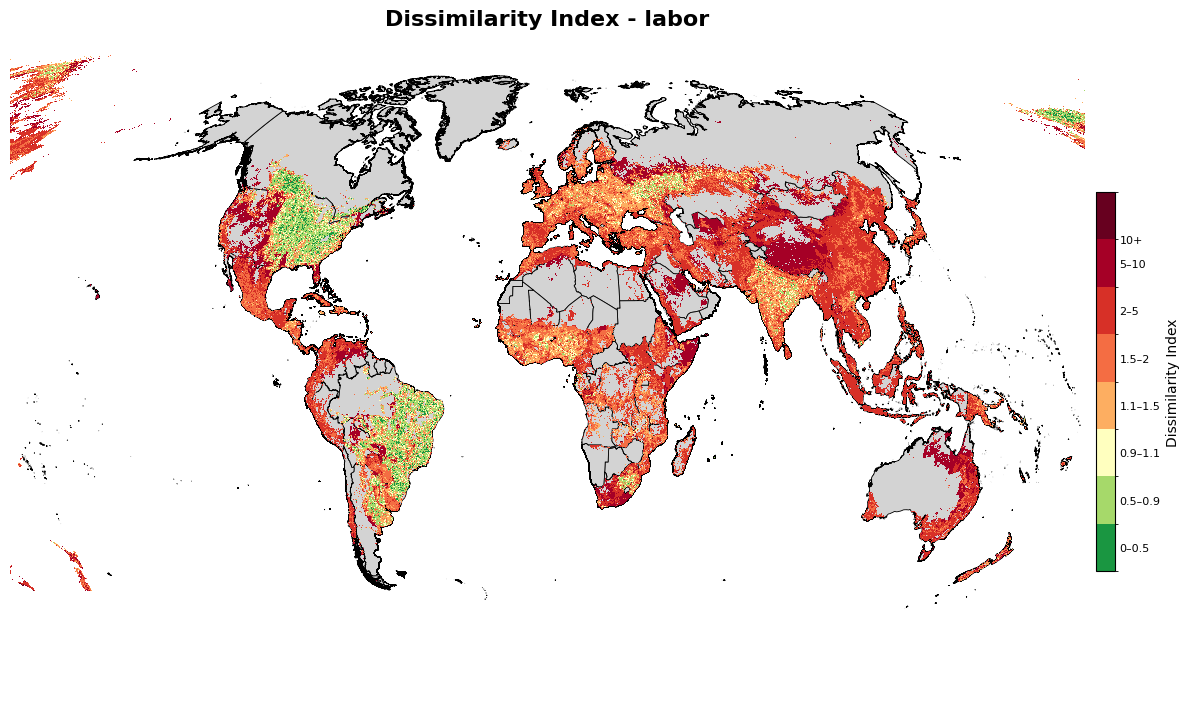

In [23]:
##### Map Dissimilarity Index

### Data prep
di_grid = rio.open_rasterio(f'{fd}/DI_{model}.tif')
production = rio.open_rasterio(f"{cd}/Data/Clean/Production/total_production_USD_2020.tif")

# align crs
crs = "ESRI:54042"
di_grid = di_grid.rio.reproject(crs)
production = production.rio.reproject(crs)  # reproject production to match
country_boundaries = country_boundaries.to_crs(crs)

# reproject production to exactly match di_grid grid
production = production.rio.reproject_match(di_grid)

# Mask nodata/fill values introduced by reprojection
di_grid = di_grid.where(di_grid > 0)

# mask di where production < 100
di_grid = di_grid.where(production.squeeze() >= 100000)

di_plot = di_grid.squeeze()

# ─────────────────────────────────────────────
# Discrete bins
# ─────────────────────────────────────────────
bins   = [0, 0.5, 0.9, 1.1, 1.5, 2, 5, 10, np.inf]
labels = ['0–0.5', '0.5–0.9', '0.9–1.1', '1.1–1.5', '1.5–2', '2–5', '5–10', '10+']
n_bins = len(labels)

colors = [
    '#1a9641',  # dark green      0–0.5
    '#a6d96a',  # light green     0.5–0.9
    '#ffffbf',  # pale yellow     0.9–1.1  (straddles DI=1)
    '#fdae61',  # light orange    1.1–1.5
    '#f46d43',  # orange          1.5–2
    '#d73027',  # red             2–5
    '#a50026',  # dark red        5–10
    '#67001f',  # very dark red   10+
]

cmap = mcolors.ListedColormap(colors)
cmap.set_bad(color='none')

# replace inf boundary with large finite number for BoundaryNorm
norm_bounds = [0, 0.5, 0.9, 1.1, 1.5, 2, 5, 10, 9999]
norm = mcolors.BoundaryNorm(boundaries=norm_bounds, ncolors=n_bins)

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

country_boundaries.plot(
    ax=ax, facecolor="lightgrey", edgecolor="black", linewidth=0.6, zorder=1
)

im = di_plot.plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=False,
    add_labels=False,
    zorder=2
)

ax.set_axis_off()
ax.set_title(f"Dissimilarity Index - {model}", fontsize=16, weight='bold', pad=20)

# ─────────────────────────────────────────────
# Colorbar with bin labels
# ─────────────────────────────────────────────
cbar = fig.colorbar(
    im, ax=ax, orientation="vertical",
    fraction=0.02, pad=0.01, shrink=0.5,
    ticks=[0.25, 0.7, 1.0, 1.3, 1.75, 3.5, 7.5, 14],  # midpoints for label placement
)
cbar.set_label("Dissimilarity Index", fontsize=10)
cbar.ax.set_yticklabels(labels, fontsize=8)
cbar.ax.tick_params(length=0)  # hide tick marks since labels are categorical

plt.tight_layout()
plt.show()
fig.savefig(f"{fd}/DI_raster_{model}.png", dpi=300, bbox_inches='tight')